In [8]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. COMBINE DATASETS
# ==========================================
# Get all CSV files in the current directory

In [9]:
csv_files = glob.glob("*.csv")
all_songs_list = []

for file in csv_files:
    # Using latin-1 to handle special characters like 'Señorita'
    df = pd.read_csv(file, encoding='latin-1')
    all_songs_list.append(df)

all_top_songs = pd.concat(all_songs_list, ignore_index=True)

# ==========================================
# 2. CLEAN DATASET (The Critical Step)
# ==========================================
# Rename columns to fix the 'Unnamed: 0' and 'dB' issues

In [10]:
all_top_songs = all_top_songs.rename(columns={
    'Unnamed: 0': 'id',
    'dB': 'db'
})

# Define the columns that MUST be numeric
numeric_cols = ['id', 'year', 'bpm', 'nrgy', 'dnce', 'db', 'live', 'val', 'dur', 'acous', 'spch', 'pop']

for col in numeric_cols:
    # Convert to numeric; 'coerce' turns non-numeric junk into NaN
    all_top_songs[col] = pd.to_numeric(all_top_songs[col], errors='coerce')

# Drop any rows that failed the conversion to ensure the dataset is clean
all_top_songs = all_top_songs.dropna(subset=numeric_cols)

# Final formatting check: Convert floats to integers where appropriate (like year/id)
all_top_songs['year'] = all_top_songs['year'].astype(int)
all_top_songs['id'] = all_top_songs['id'].astype(int)

# ==========================================
# 3. CORE ANALYSIS
# ==========================================

In [12]:
# Q1: Most popular song
most_popular = all_top_songs.nlargest(1, 'pop')
print(f"Most Popular Song: {most_popular['title'].values[0]} by {most_popular['artist'].values[0]}")

Most Popular Song: Memories by Maroon 5


In [13]:
# Q2: Artist with most songs
top_artist = all_top_songs['artist'].value_counts().idxmax()
print(f"Artist with most songs: {top_artist}")

Artist with most songs: Katy Perry


In [14]:
# Q3: Most popular genre
top_genre = all_top_songs['top genre'].value_counts().idxmax()
print(f"Most popular genre: {top_genre}")

Most popular genre: dance pop


In [15]:
# Q4: Duplicate songs
duplicates = all_top_songs.duplicated(subset=['title', 'artist']).sum()
print(f"Number of duplicate songs: {duplicates}")

Number of duplicate songs: 16


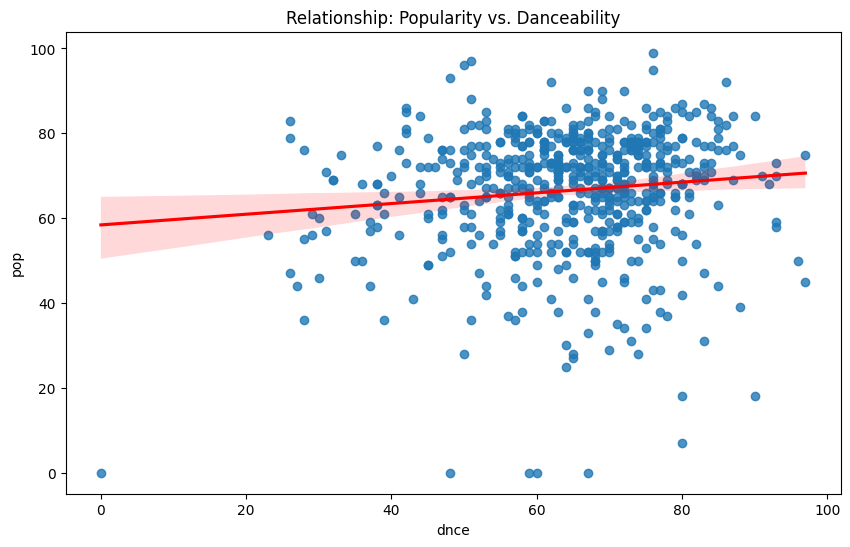

In [16]:
# Q5: Popularity vs. Danceability Relationship
plt.figure(figsize=(10, 6))
sns.regplot(x='dnce', y='pop', data=all_top_songs, line_kws={"color": "red"})
plt.title('Relationship: Popularity vs. Danceability')
plt.show()

In [17]:
# Q6: High BPM leads to higher Energy?
correlation_bpm_energy = all_top_songs['bpm'].corr(all_top_songs['nrgy'])
print(f"Correlation between BPM and Energy: {correlation_bpm_energy:.2f}")

Correlation between BPM and Energy: 0.13


In [18]:
# Q7: Genre with highest energy score
highest_energy_genre = all_top_songs.groupby('top genre')['nrgy'].mean().idxmax()
print(f"Highest energy genre: {highest_energy_genre}")

Highest energy genre: french indie pop


# ==========================================
# 4. EXTRA CREDIT
# ==========================================

In [19]:
# EC: Export to CSV
all_top_songs.to_csv('top_spotify_songs.csv', index=False)

In [20]:
# EC: Percentage of live recordings (> 50)
live_count = len(all_top_songs[all_top_songs['live'] > 50])
print(f"Percentage of live songs: {(live_count / len(all_top_songs)) * 100:.2f}%")

Percentage of live songs: 2.99%


In [21]:
# EC: Percentage of acoustic songs (> 50)
acous_count = len(all_top_songs[all_top_songs['acous'] > 50])
print(f"Percentage of acoustic songs: {(acous_count / len(all_top_songs)) * 100:.2f}%")

Percentage of acoustic songs: 7.30%


In [22]:
# EC: Year with highest amount of spoken word
top_spch_year = all_top_songs.groupby('year')['spch'].mean().idxmax()
print(f"Year with highest spoken word: {top_spch_year}")

Year with highest spoken word: 2017
